# Gradient Descent - Simple Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# synthetic dataset
from sklearn.datasets import make_regression
x,y = make_regression(n_samples = 1000, n_features = 1, n_informative = 1, n_targets = 1, noise = 25)

In [3]:
# to dataframe
df = pd.DataFrame({
    'feat':x[:,0],
    'target':y
})
df.head()

,feat,target
0,0.775489,55.091581
1,1.523724,-7.807297
2,0.208144,14.689947
3,0.759642,34.250856
4,-1.841895,-55.392414


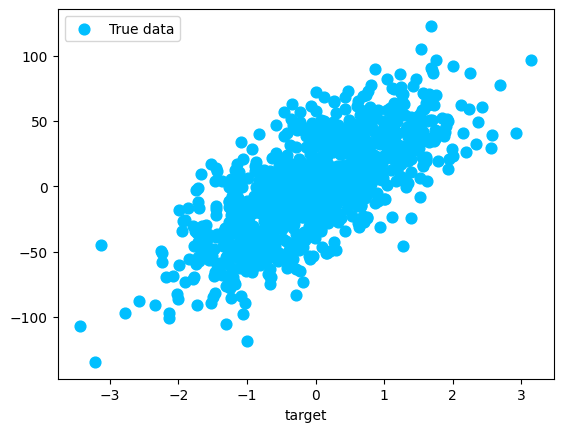

In [11]:
# plotting the exisitng points
plt.scatter(x,y,color = 'deepskyblue', label = 'True data', s = 60)
plt.xlabel('feature')
plt.xlabel('target')
plt.legend()
plt.show()

# training sklearn linear Regression for comparison purpose

In [5]:
# data split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 2)

In [6]:
# linear regression - model training
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [7]:
# predictions
y_pred = lr.predict(x_test)

In [8]:
lr.coef_  # m

array([27.78221405])

In [9]:
lr.intercept_  # b

np.float64(1.099418717117128)

In [10]:
# evauation
from sklearn.metrics import r2_score
r2_lr = r2_score(y_test, y_pred)
r2_lr

0.513468949501553

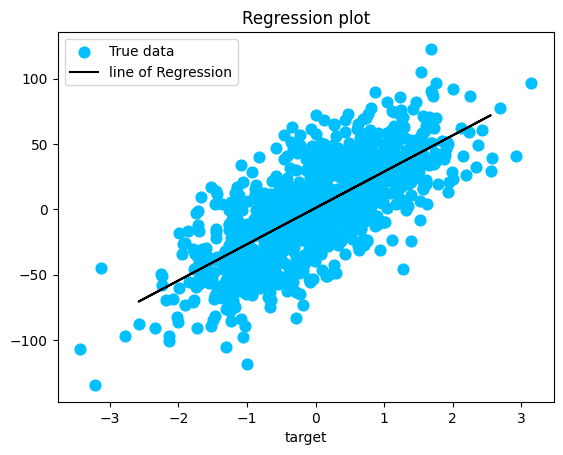

In [13]:
# best fit line
plt.scatter(x,y,color = 'deepskyblue', label = 'True data', s = 60)
plt.plot(x_test, y_pred, color = 'k', label = 'line of Regression')
plt.xlabel('feature')
plt.xlabel('target')
plt.title('Regression plot')
plt.legend()
plt.show()

In [15]:
# Gradient descent class
class gradient_desc:
  def __init__(self, learning_rate, epochs):
    self.m = 0 # random init
    self.b = 1 # random init
    self.n = learning_rate
    self.epochs = epochs
    self.loss_list = []

  def fit(self, x_train, y_train):
    for i in range(self.epochs):
      # updating the intercept (b)
      loss_slope_b = (-2/x_train.shape[0]) * np.sum(y_train - self.m * x_train.ravel() - self.b)
      self.b -= (self.n * loss_slope_b)

      # updating the slope (m)
      loss_slope_m = (-2/x_train.shape[0]) * np.sum((y_train - self.m * x_train.ravel() - self.b) * (x_train.ravel()))
      self.m -= (self.n * loss_slope_m)

      y_pred = self.m * x_train.ravel() + self.b
      loss = np.mean((y_train - y_pred)**2)

      self.loss_list.append(loss)
      print(f"step {i} | loss = {loss}")

    print('Final parameters:')
    print('m = ',self.m)
    print('b = ',self.b)

  def predict(self, x_test):
    return self.m * x_test + self.b

In [17]:
# training the GD class model
gd = gradient_desc(0.1, 100)
gd.fit(x_train, y_train)

step 0 | loss = 1148.9036731974118
step 1 | loss = 990.8982665916126
step 2 | loss = 885.7394997022409
step 3 | loss = 815.7398768220758
step 4 | loss = 769.136273075962
step 5 | loss = 738.1039784335875
step 6 | loss = 717.4370485203564
step 7 | loss = 703.6712019643502
step 8 | loss = 694.5007223418455
step 9 | loss = 688.390729185701
step 10 | loss = 684.3193044074951
step 11 | loss = 681.6059489937028
step 12 | loss = 679.7974462269071
step 13 | loss = 678.5919062201134
step 14 | loss = 677.7882101402367
step 15 | loss = 677.2523545776778
step 16 | loss = 676.8950428383802
step 17 | loss = 676.6567623234081
step 18 | loss = 676.4978455973729
step 19 | loss = 676.3918497803688
step 20 | loss = 676.3211457521214
step 21 | loss = 676.2739791873688
step 22 | loss = 676.2425120377459
step 23 | loss = 676.2215172199878
step 24 | loss = 676.2075085502158
step 25 | loss = 676.198160729585
step 26 | loss = 676.1919226460616
step 27 | loss = 676.1877595344221
step 28 | loss = 676.18498103855

In [18]:
# prediction
y_pred_gd = gd.predict(x_test)

In [19]:
# r2_Score
r2_gd = r2_score(y_test, y_pred_gd)
r2_gd

0.5134689494410785

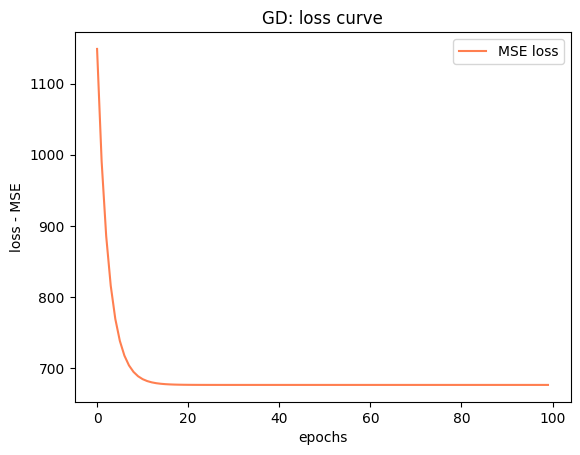

In [22]:
# loss curve GD
plt.plot(range(gd.epochs), gd.loss_list, color = 'coral', label = 'MSE loss')
plt.xlabel('epochs')
plt.ylabel('loss - MSE')
plt.title('GD: loss curve')
plt.legend()
plt.show()